# Notebook 04 — Hough Transform & Geometric Filtering (refined merge)

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 4:** Edge map → Probabilistic Hough → geometric filtering → continuity-aware segment merging

This version is adapted to the current outputs of the previous notebooks:

- Edge maps from `outputs/03_canny/`
- Calibration data from `outputs/02_rectified_clean/calibration.json`
- Debug plots saved separately in `outputs/04_hough/debug/`

The important refinement in this notebook is the merge step: vertical Hough segments are merged only when they are close in **x** and also continuous or almost continuous in **y**. This prevents disconnected segments from different rubber pieces being merged into one unrealistic long line.


## 1. Imports and configuration

In [10]:
# Install only if needed
# !pip install opencv-python numpy matplotlib

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [12]:
# ── Paths ──────────────────────────────────────────────────────────────────
CANNY_DIR  = Path("outputs/03_canny")
CALIB_PATH = Path("outputs/02_rectified/calibration.json")
OUTPUT_DIR = Path("outputs/04_hough")
DEBUG_DIR  = OUTPUT_DIR / "debug"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

# ── Probabilistic Hough parameters ─────────────────────────────────────────
HOUGH_RHO        = 1
HOUGH_THETA      = np.pi / 180
HOUGH_THRESHOLD  = 50
HOUGH_MIN_LEN    = 80
HOUGH_MAX_GAP    = 30

# ── Geometric filter parameters ────────────────────────────────────────────
# Current baseline: near-vertical line segments.
MAX_ANGLE_FROM_VERTICAL = 25

# Since NB02 rectifies images to an 800x800 metric image, spatial filtering
# is applied in the rectified coordinate system, not with original QR pixels.
SPATIAL_MARGIN_X = 20
SPATIAL_MARGIN_Y = 20

# ── Merging parameters ─────────────────────────────────────────────────────
# Previous merge only grouped by x and could create unrealistically long lines.
# New merge requires similar x AND vertical continuity.
MERGE_X_THR = 18          # max x distance to group vertical segments
MERGE_Y_GAP_THR = 45      # max vertical gap allowed inside the same merged line
MIN_MERGED_LENGTH = 45    # discard merged lines shorter than this

# ── Expected detections ────────────────────────────────────────────────────
EXPECTED_EDGES = 4

# ── Dataset filtering ──────────────────────────────────────────────────────
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}
DATASET_PREFIX = "Multimedia_"

# Load calibration from clean NB02
with open(CALIB_PATH, encoding="utf-8") as f:
    calibration_data = json.load(f)

print(f"Canny dir        : {CANNY_DIR.resolve()}")
print(f"Calibration path : {CALIB_PATH.resolve()}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")
print(f"Debug dir        : {DEBUG_DIR.resolve()}")
print(f"Calibrated images: {len(calibration_data)}")


Canny dir        : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny
Calibration path : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified\calibration.json
Output dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\04_hough
Debug dir        : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\04_hough\debug
Calibrated images: 20


## 2. Probabilistic Hough Transform

In [13]:
def run_hough(edges: np.ndarray) -> np.ndarray | None:
    """Run Probabilistic Hough Transform. Returns (N, 1, 4) array or None."""
    return cv2.HoughLinesP(
        edges,
        rho=HOUGH_RHO,
        theta=HOUGH_THETA,
        threshold=HOUGH_THRESHOLD,
        minLineLength=HOUGH_MIN_LEN,
        maxLineGap=HOUGH_MAX_GAP
    )

## 3. Geometric filtering

The previous version used QR corner coordinates from the original image. The current NB02 outputs **rectified 800x800 images**, so here the spatial filter uses the rectified image bounds directly.


In [14]:
def angle_from_vertical(x1: int, y1: int, x2: int, y2: int) -> float:
    """Angle in degrees between a segment and the vertical axis."""
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    return 90.0 if dy == 0 else float(np.degrees(np.arctan2(dx, dy)))


def get_spatial_bounds(img_shape: tuple) -> tuple[int, int, int, int]:
    """Return spatial bounds in rectified image coordinates."""
    H, W = img_shape
    x_min = SPATIAL_MARGIN_X
    x_max = W - SPATIAL_MARGIN_X
    y_min = SPATIAL_MARGIN_Y
    y_max = H - SPATIAL_MARGIN_Y
    return x_min, x_max, y_min, y_max


def filter_segments(segments, img_shape: tuple) -> list:
    """
    Filter Hough segments by orientation and spatial position.

    Current version keeps near-vertical segments inside the rectified image
    bounds. This keeps the filtering consistent with NB02 clean outputs.
    """
    if segments is None:
        return []

    x_min, x_max, y_min, y_max = get_spatial_bounds(img_shape)

    filtered = []

    for seg in segments:
        x1, y1, x2, y2 = seg[0]

        if angle_from_vertical(x1, y1, x2, y2) > MAX_ANGLE_FROM_VERTICAL:
            continue

        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2

        if not (x_min <= mx <= x_max and y_min <= my <= y_max):
            continue

        filtered.append([int(x1), int(y1), int(x2), int(y2)])

    return filtered

## 4. Continuity-aware segment merging

The previous merge grouped vertical segments only by similar x-coordinate. That could incorrectly merge disconnected segments from different rubber pieces into one very long line.

This version uses two criteria:

1. similar x-coordinate;
2. small vertical gap between consecutive segments.

So two segments are merged only if they are close and almost continuous in the y-direction.


In [15]:
def build_merged_vertical_segment(group: list) -> list | None:
    """
    Build one vertical segment from a group of close and continuous segments.

    Input group contains normalized dictionaries with:
      - x
      - y_min
      - y_max
      - segment

    Returns:
      [x_mean, y_top, x_mean, y_bottom] or None if too short.
    """
    x_mean = int(round(np.mean([s["x"] for s in group])))
    y_top = int(round(min(s["y_min"] for s in group)))
    y_bottom = int(round(max(s["y_max"] for s in group)))

    length = y_bottom - y_top

    if length < MIN_MERGED_LENGTH:
        return None

    return [x_mean, y_top, x_mean, y_bottom]


def merge_vertical_segments(segments: list) -> list:
    """
    Merge vertical Hough segments only if they are:
      1. close in x-coordinate;
      2. continuous or almost continuous in y-coordinate.

    This prevents disconnected cut edges from different rubber pieces from
    being merged into a single unrealistic long line.
    """
    if len(segments) == 0:
        return []

    # Normalize each segment as a vertical interval.
    norm_segments = []

    for seg in segments:
        x1, y1, x2, y2 = seg

        x_mean = float((x1 + x2) / 2)
        y_min = float(min(y1, y2))
        y_max = float(max(y1, y2))

        norm_segments.append({
            "x": x_mean,
            "y_min": y_min,
            "y_max": y_max,
            "segment": seg,
        })

    # First grouping: segments with similar x-coordinate.
    norm_segments = sorted(norm_segments, key=lambda s: s["x"])

    x_groups = []

    for seg in norm_segments:
        placed = False

        for group in x_groups:
            group_x = np.mean([s["x"] for s in group])

            if abs(seg["x"] - group_x) <= MERGE_X_THR:
                group.append(seg)
                placed = True
                break

        if not placed:
            x_groups.append([seg])

    # Second grouping inside each x group: vertical continuity.
    merged = []

    for group in x_groups:
        group = sorted(group, key=lambda s: s["y_min"])

        current_component = [group[0]]

        for seg in group[1:]:
            current_y_max = max(s["y_max"] for s in current_component)
            vertical_gap = seg["y_min"] - current_y_max

            if vertical_gap <= MERGE_Y_GAP_THR:
                current_component.append(seg)
            else:
                merged_segment = build_merged_vertical_segment(current_component)

                if merged_segment is not None:
                    merged.append(merged_segment)

                current_component = [seg]

        # Close last component.
        merged_segment = build_merged_vertical_segment(current_component)

        if merged_segment is not None:
            merged.append(merged_segment)

    return merged


## 5. Full pipeline per image

In [16]:
def process_image(image_name: str) -> dict | None:
    """Run Hough detection for one edge map."""
    edge_path = CANNY_DIR / image_name
    edges = cv2.imread(str(edge_path), cv2.IMREAD_GRAYSCALE)

    if edges is None:
        print(f"  [SKIP] Missing edge map: {image_name}")
        return None

    H, W = edges.shape

    raw_segments = run_hough(edges)
    filtered_segments = filter_segments(raw_segments, (H, W))
    merged_edges = merge_vertical_segments(filtered_segments)

    return {
        "image_name": image_name,
        "n_raw": int(len(raw_segments)) if raw_segments is not None else 0,
        "n_filtered": int(len(filtered_segments)),
        "n_merged": int(len(merged_edges)),
        "cut_edges_px": merged_edges,
        "orientation_mode": "vertical",
        "hough_params": {
            "rho": HOUGH_RHO,
            "theta": float(HOUGH_THETA),
            "threshold": HOUGH_THRESHOLD,
            "minLineLength": HOUGH_MIN_LEN,
            "maxLineGap": HOUGH_MAX_GAP,
        },
        "filter_params": {
            "max_angle_from_vertical": MAX_ANGLE_FROM_VERTICAL,
            "spatial_margin_x": SPATIAL_MARGIN_X,
            "spatial_margin_y": SPATIAL_MARGIN_Y,
        },
        "merge_params": {
            "merge_x_thr": MERGE_X_THR,
            "merge_y_gap_thr": MERGE_Y_GAP_THR,
            "min_merged_length": MIN_MERGED_LENGTH,
        },
    }


In [17]:
image_names = sorted([
    name for name in calibration_data.keys()
    if (CANNY_DIR / name).exists()
    and Path(name).suffix.lower() in VALID_EXTENSIONS
    and Path(name).name.startswith(DATASET_PREFIX)
])

print(f"Found {len(image_names)} edge maps matching calibration data\n")

hough_results = {}

for image_name in image_names:
    result = process_image(image_name)

    if result is None:
        continue

    hough_results[image_name] = result

    flag = "✓" if result["n_merged"] == EXPECTED_EDGES else "✗"

    print(
        f"  [{flag}] {image_name:30s}  "
        f"raw={result['n_raw']:4d}  "
        f"filtered={result['n_filtered']:3d}  "
        f"merged={result['n_merged']:2d}"
    )

correct = sum(1 for r in hough_results.values() if r["n_merged"] == EXPECTED_EDGES)
print(f"\nCorrect (n={EXPECTED_EDGES}): {correct} / {len(hough_results)} images")

# Save for NB05 and NB06
lines_path = OUTPUT_DIR / "lines.json"
with open(lines_path, "w", encoding="utf-8") as f:
    json.dump(hough_results, f, indent=2)

print(f"Saved to {lines_path}")

Found 20 edge maps matching calibration data

  [✗] Multimedia_31.jpg               raw=  99  filtered= 34  merged= 5
  [✗] Multimedia_32.jpg               raw= 124  filtered= 48  merged= 7
  [✗] Multimedia_33.jpg               raw=  93  filtered= 41  merged= 6
  [✓] Multimedia_34.jpg               raw=  93  filtered= 28  merged= 4
  [✗] Multimedia_35.jpg               raw=  93  filtered= 53  merged= 8
  [✗] Multimedia_36.jpg               raw=  89  filtered= 54  merged= 6
  [✗] Multimedia_37.jpg               raw= 126  filtered= 72  merged= 8
  [✓] Multimedia_39.jpg               raw=  90  filtered= 21  merged= 4
  [✓] Multimedia_40.jpg               raw=  83  filtered= 22  merged= 4
  [✗] Multimedia_41.jpg               raw=  66  filtered= 13  merged= 2
  [✗] Multimedia_42.jpg               raw=  80  filtered= 29  merged= 6
  [✗] Multimedia_43.jpg               raw= 110  filtered= 36  merged= 6
  [✗] Multimedia_45.jpg               raw=  80  filtered= 58  merged= 7
  [✗] Multimedia_4

## 6. Visual inspection

In [18]:
def visualize_result(image_name: str, show: bool = True):
    """Save and optionally show visual debug output for one image."""
    if image_name not in hough_results:
        print(f"Image not found in hough_results: {image_name}")
        return

    result = hough_results[image_name]
    edges = cv2.imread(str(CANNY_DIR / image_name), cv2.IMREAD_GRAYSCALE)

    if edges is None:
        print(f"Missing edge map: {image_name}")
        return

    H, W = edges.shape

    raw_segments = run_hough(edges)
    filtered_segments = filter_segments(raw_segments, (H, W))
    merged_edges = result["cut_edges_px"]

    x_min, x_max, y_min, y_max = get_spatial_bounds((H, W))

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(
        f"{image_name} — raw={result['n_raw']}  "
        f"filtered={result['n_filtered']}  "
        f"merged={result['n_merged']}  "
        f"expected={EXPECTED_EDGES}",
        fontsize=12
    )

    # Edge map + spatial bounds
    edge_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(edge_vis, (x_min, y_min), (x_max, y_max), (0, 100, 255), 2)
    axes[0].imshow(edge_vis)
    axes[0].set_title("Edge map + spatial bounds")
    axes[0].axis("off")

    # Filtered Hough segments
    filt_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    for x1, y1, x2, y2 in filtered_segments:
        cv2.line(filt_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[1].imshow(filt_vis)
    axes[1].set_title(f"Filtered segments (n={len(filtered_segments)})")
    axes[1].axis("off")

    # Merged cut edges
    merge_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    colors = [(255, 0, 0), (0, 200, 255), (255, 165, 0), (0, 255, 0)]

    for i, (x1, y1, x2, y2) in enumerate(merged_edges):
        color = colors[i % len(colors)]
        cv2.line(merge_vis, (x1, y1), (x2, y2), color, 3)
        cv2.circle(merge_vis, (x1, y1), 5, (255, 255, 0), -1)
        cv2.circle(merge_vis, (x2, y2), 5, (255, 255, 0), -1)

    axes[2].imshow(merge_vis)
    axes[2].set_title(f"Merged cut edges (n={len(merged_edges)})")
    axes[2].axis("off")

    plt.tight_layout()

    out_path = DEBUG_DIR / f"check_{Path(image_name).stem}.png"
    plt.savefig(out_path, dpi=120)

    if show:
        plt.show()
    else:
        plt.close()

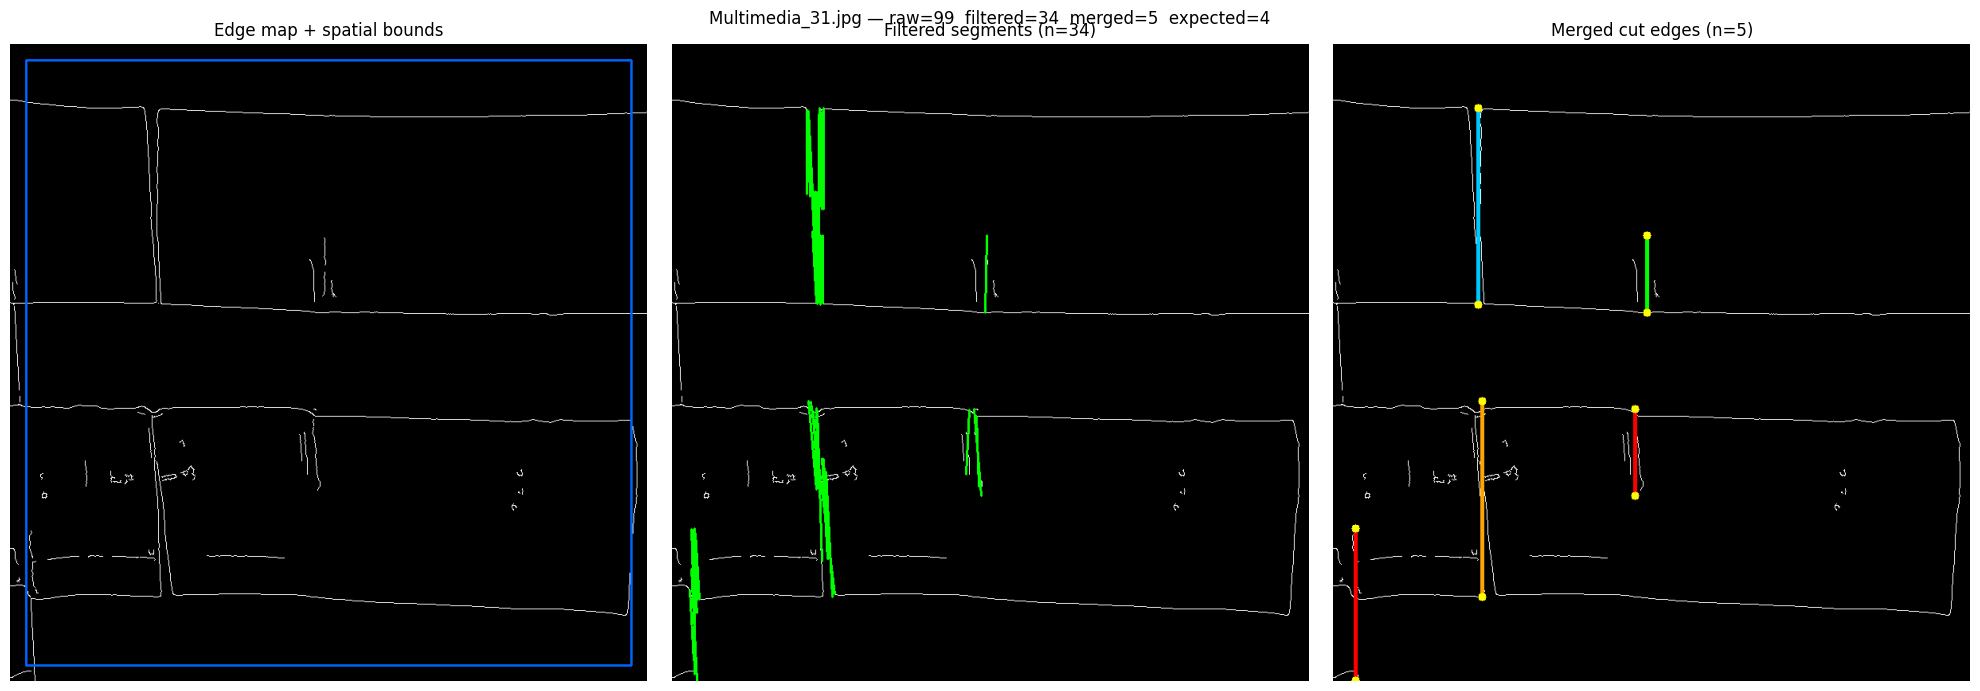

In [19]:
# Show first image and save its debug figure
if hough_results:
    visualize_result(next(iter(hough_results)), show=True)
else:
    print("No Hough results available.")

In [20]:
# Optional: save debug visualizations for all images without displaying them
for name in hough_results:
    visualize_result(name, show=False)

print(f"Saved debug visualizations to {DEBUG_DIR}")

Saved debug visualizations to outputs\04_hough\debug


## 7. Detection summary across all images

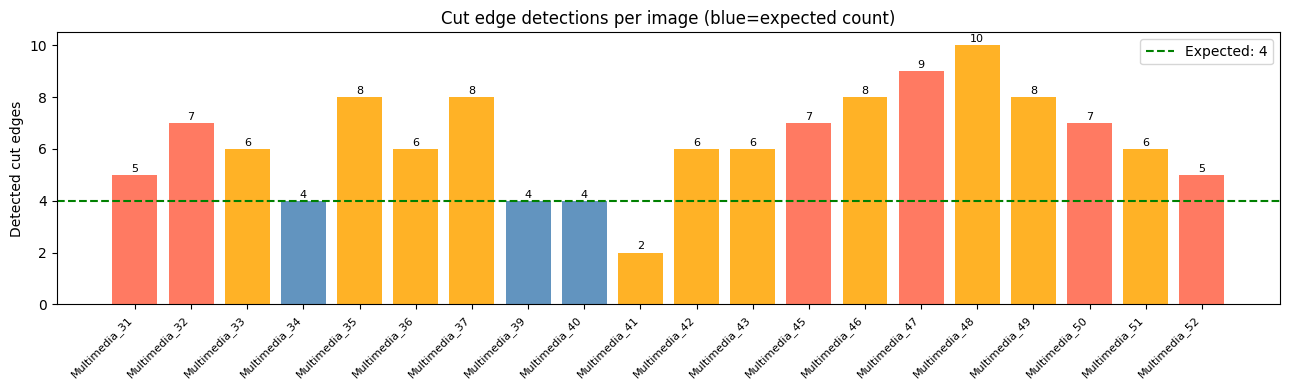

Correct (n=4) : 3 / 20
Even wrong count       : 11 / 20
Odd count              : 6 / 20


In [21]:
names = list(hough_results.keys())
n_edges = [hough_results[n]["n_merged"] for n in names]

if names:
    fig, ax = plt.subplots(figsize=(13, 4))

    bar_colors = [
        "steelblue" if n == EXPECTED_EDGES else
        "tomato" if n % 2 != 0 else
        "orange"
        for n in n_edges
    ]

    ax.bar(range(len(names)), n_edges, color=bar_colors, alpha=0.85)

    for i, n in enumerate(n_edges):
        ax.text(i, n + 0.05, str(n), ha="center", va="bottom", fontsize=8)

    ax.axhline(EXPECTED_EDGES, color="green", linestyle="--", label=f"Expected: {EXPECTED_EDGES}")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([Path(n).stem for n in names], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Detected cut edges")
    ax.set_title("Cut edge detections per image (blue=expected count)")
    ax.legend()

    plt.tight_layout()
    plt.savefig(DEBUG_DIR / "detection_summary.png", dpi=150)
    plt.show()

    correct = sum(1 for n in n_edges if n == EXPECTED_EDGES)
    even_wrong = sum(1 for n in n_edges if n != EXPECTED_EDGES and n % 2 == 0)
    odd = sum(1 for n in n_edges if n % 2 != 0)

    print(f"Correct (n={EXPECTED_EDGES}) : {correct} / {len(names)}")
    print(f"Even wrong count       : {even_wrong} / {len(names)}")
    print(f"Odd count              : {odd} / {len(names)}")
else:
    print("No results to summarize.")

## 8. Summary

| Step | Operation | Parameters |
|------|-----------|------------|
| 4a | Probabilistic Hough | `threshold=50`, `minLen=80`, `maxGap=30` |
| 4b | Orientation filter | near-vertical, `max angle = 25°` |
| 4c | Spatial filter | rectified image bounds with margins |
| 4d | Segment merging | similar x + vertical continuity |

**Important change:** the merge now avoids joining disconnected vertical segments that only share a similar x-coordinate.

**Output folder:** `outputs/04_hough/`  
**Lines file:** `outputs/04_hough/lines.json`  
**Debug folder:** `outputs/04_hough/debug/`  
**Used by:** NB05, NB06  
**Next notebook:** `05_metric.ipynb`
